Import library

In [51]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import wandb

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset
from accelerate.state import PartialState
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import numpy as np

GPU Hardware

In [52]:
print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(
        f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )
else:
    device = torch.device("cpu")
    print("WARNING: CUDA is not available. Running on CPU.")

Python Version: 3.13.5
PyTorch Version: 2.11.0+cu126
CUDA Available: True
GPU Device Name: NVIDIA GeForce RTX 4050 Laptop GPU
Total VRAM: 6.44 GB


Load Dataset

In [7]:
print("--- Loading Sarcasm Detection Dataset ---")

sarcasm_json_path = "D:\\sentiment and sarcasm analysis\\data\\raw\\Sarcasm_Headlines_Dataset.json"

if not os.path.exists(sarcasm_json_path):
    raise FileNotFoundError(
        f"Could not find the dataset at {sarcasm_json_path}. Please check your data/ folder!"
    )

# The Kaggle dataset is usually in JSON Lines format (one JSON object per line)
data_lines = []
with open(sarcasm_json_path, "r", encoding="utf-8") as f:
    for line in f:
        data_lines.append(json.loads(line))

# Convert to DataFrame
sarcasm_df = pd.DataFrame(data_lines)

print(f"Sarcasm Dataset Shape: {sarcasm_df.shape}")
print("\n[First 3 Rows of Sarcasm Data]:")
print(sarcasm_df[["headline", "is_sarcastic"]].head(3))

--- Loading Sarcasm Detection Dataset ---
Sarcasm Dataset Shape: (26709, 3)

[First 3 Rows of Sarcasm Data]:
                                            headline  is_sarcastic
0  former versace store clerk sues over secret 'b...             0
1  the 'roseanne' revival catches up to our thorn...             0
2  mom starting to fear son's web series closest ...             1


Calculate word counts for the raw headlines

In [20]:
sarcasm_df["word_count"] = sarcasm_df["headline"].apply(
    lambda x: len(str(x).split())
)

print("\n[Headline Word Count Statistics]:")
print(sarcasm_df["word_count"].describe())


[Headline Word Count Statistics]:
count    26709.000000
mean         9.845820
std          3.168955
min          2.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         39.000000
Name: word_count, dtype: float64


Check Class Balance

In [21]:
print("\n[Class Balance Breakdown (0 = Normal, 1 = Sarcastic)]:")
print(sarcasm_df["is_sarcastic"].value_counts())
print(sarcasm_df["is_sarcastic"].value_counts(normalize=True))


[Class Balance Breakdown (0 = Normal, 1 = Sarcastic)]:
is_sarcastic
0    14985
1    11724
Name: count, dtype: int64
is_sarcastic
0    0.561047
1    0.438953
Name: proportion, dtype: float64


Generate Visualizations

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_520\3199088296.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


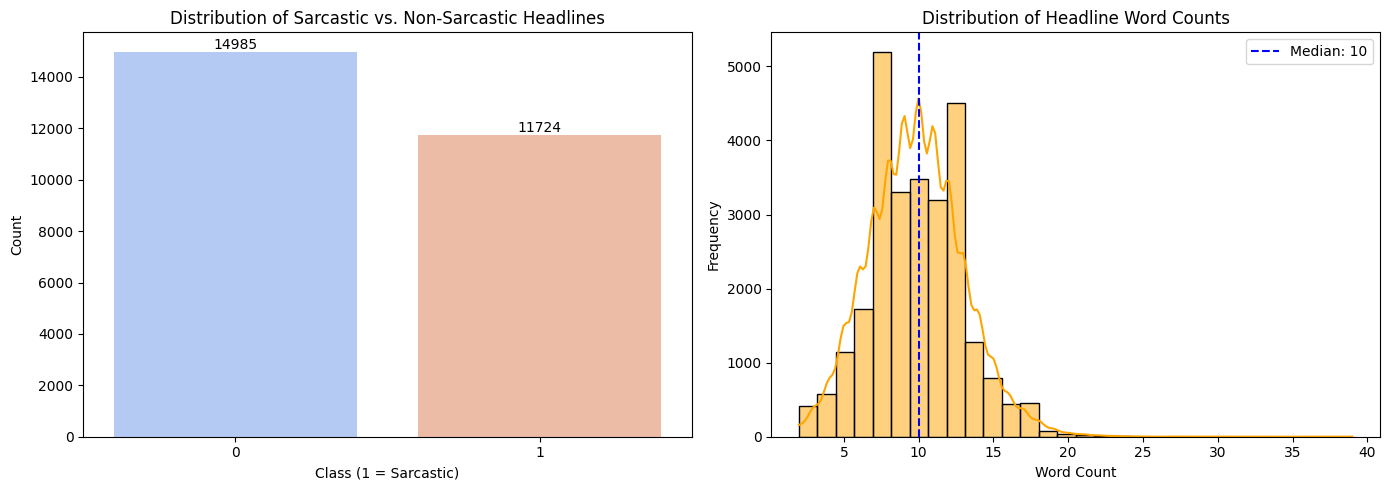

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Class Balance Chart
sns.countplot(
    x="is_sarcastic", data=sarcasm_df, ax=axes[0], palette="coolwarm"
)
axes[0].set_title("Distribution of Sarcastic vs. Non-Sarcastic Headlines")
axes[0].set_xlabel("Class (1 = Sarcastic)")
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container)

# Plot B: Headline Length Distribution Histogram
sns.histplot(sarcasm_df["word_count"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].axvline(
    sarcasm_df["word_count"].median(),
    color="blue",
    linestyle="--",
    label=f"Median: {sarcasm_df['word_count'].median():.0f}",
)
axes[1].set_title("Distribution of Headline Word Counts")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

Data Split

In [23]:
sarc_train_df, sarc_val_test_df = train_test_split(
    sarcasm_df, test_size=0.20, random_state=42, stratify=sarcasm_df["is_sarcastic"]
)

sarc_val_df, sarc_test_df = train_test_split(
    sarc_val_test_df,
    test_size=0.50,
    random_state=42,
    stratify=sarc_val_test_df["is_sarcastic"],
)

print("\n=== Sarcasm Data Split Verification ===")
print(
    f"Train Dataset Size:      {len(sarc_train_df)} rows ({len(sarc_train_df)/len(sarcasm_df)*100:.0f}%)"
)
print(
    f"Validation Dataset Size: {len(sarc_val_df)} rows ({len(sarc_val_df)/len(sarcasm_df)*100:.0f}%)"
)
print(
    f"Test Dataset Size:       {len(sarc_test_df)} rows ({len(sarc_test_df)/len(sarcasm_df)*100:.0f}%)"
)


=== Sarcasm Data Split Verification ===
Train Dataset Size:      21367 rows (80%)
Validation Dataset Size: 2671 rows (10%)
Test Dataset Size:       2671 rows (10%)


Text Normalization Function for Headlines

In [24]:
def clean_headline_text(text):
    # Ensure standard string format
    text = str(text)
    # Collapse any double spaces or tab spaces down into a single space
    clean_text = re.sub(r'\s+', ' ', text)
    return clean_text.strip()

# Apply the cleaning step across our specific split dataframes
sarc_train_df = sarc_train_df.copy()
sarc_val_df = sarc_val_df.copy()
sarc_test_df = sarc_test_df.copy()

sarc_train_df['headline_clean'] = sarc_train_df['headline'].apply(clean_headline_text)
sarc_val_df['headline_clean'] = sarc_val_df['headline'].apply(clean_headline_text)
sarc_test_df['headline_clean'] = sarc_test_df['headline'].apply(clean_headline_text)

print("Headline preprocessing completed successfully.")

Headline preprocessing completed successfully.


Initialize a separate Weights & Biases run for the sarcasm baseline

In [25]:
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [26]:
run = wandb.init(
    project="sentiment-sarcasm-analysis",
    name="tfidf_logistic_regression_sarcasm",
    config={
        "vectorizer": "TF-IDF",
        "max_features": 10000,
        "ngram_range": (1, 2),
        "model": "Logistic Regression",
        "C": 1.0,
        "split": "80-10-10",
        "task": "Sarcasm Detection"
    }
)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Extract Headline Text Features using TF-IDF

In [27]:
print("Vectorizing headline text data...")
sarcasm_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit on training headlines; transform validation and testing splits
X_sarc_train = sarcasm_vectorizer.fit_transform(sarc_train_df['headline'])
X_sarc_val = sarcasm_vectorizer.transform(sarc_val_df['headline'])
X_sarc_test = sarcasm_vectorizer.transform(sarc_test_df['headline'])

y_sarc_train = sarc_train_df['is_sarcastic'].values
y_sarc_val = sarc_val_df['is_sarcastic'].values
y_sarc_test = sarc_test_df['is_sarcastic'].values

Vectorizing headline text data...


Train Classical Machine Learning Baseline

In [28]:
print("Training Logistic Regression baseline...")
sarc_baseline_model = LogisticRegression(max_iter=1000, random_state=42)
sarc_baseline_model.fit(X_sarc_train, y_sarc_train)

Training Logistic Regression baseline...


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Predict and Evaluate on Sarcasm Validation Split

In [29]:
sarc_val_preds = sarc_baseline_model.predict(X_sarc_val)

sarc_val_accuracy = accuracy_score(y_sarc_val, sarc_val_preds)
sarc_val_f1 = f1_score(y_sarc_val, sarc_val_preds, average='macro')

print("\n=== Sarcasm Validation Results ===")
print(f"Validation Accuracy: {sarc_val_accuracy:.4f}")
print(f"Validation Macro F1: {sarc_val_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_sarc_val, sarc_val_preds, target_names=['not_sarcastic', 'sarcastic']))


=== Sarcasm Validation Results ===
Validation Accuracy: 0.8499
Validation Macro F1: 0.8473

Classification Report:
               precision    recall  f1-score   support

not_sarcastic       0.86      0.87      0.87      1498
    sarcastic       0.84      0.82      0.83      1173

     accuracy                           0.85      2671
    macro avg       0.85      0.85      0.85      2671
 weighted avg       0.85      0.85      0.85      2671



Log metrics and baseline matrix data to WandB cloud platform

In [30]:
print("Logging experiments to Weights & Biases...")
wandb.log({
    "sarcasm_val_accuracy": sarc_val_accuracy,
    "sarcasm_val_f1_score": sarc_val_f1
})

wandb.log({"sarcasm_conf_mat": wandb.plot.confusion_matrix(
    probs=None,
    y_true=y_sarc_val,
    preds=sarc_val_preds,
    class_names=['not_sarcastic', 'sarcastic']
)})

run.finish()
print("\nSarcasm baseline training run completed successfully!")

Logging experiments to Weights & Biases...


sarcasm_val_accuracy,▁
sarcasm_val_f1_score,▁
sarcasm_val_accuracy,0.84987
sarcasm_val_f1_score,0.84731



Sarcasm baseline training run completed successfully!


Load the official pre-trained BERT tokenizer

In [32]:
sarc_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Define our custom PyTorch Dataset class optimized for short headlines

In [33]:
class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Using the recommended direct call convention to avoid compatibility errors
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,        # Automatically inserts '[CLS]' and '[SEP]' tokens
            max_length=self.max_len,
            padding='max_length',           # Pads text out to 64 tokens
            truncation=True,                # Safely truncates anything over 64 tokens
            return_attention_mask=True,     # Generates the attention mask matrix
            return_tensors='pt',            # Output native PyTorch tensors
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Tokenizing and constructing PyTorch Sarcasm Datasets...")

Tokenizing and constructing PyTorch Sarcasm Datasets...


Create instances for our new Train and Validation splits

In [34]:
sarc_train_dataset = SarcasmDataset(sarc_train_df['headline_clean'], sarc_train_df['is_sarcastic'], sarc_tokenizer, max_len=64)
sarc_val_dataset = SarcasmDataset(sarc_val_df['headline_clean'], sarc_val_df['is_sarcastic'], sarc_tokenizer, max_len=64)

print(f"Sarcasm Train dataset wrapper complete: {len(sarc_train_dataset)} samples.")
print(f"Sarcasm Validation dataset wrapper complete: {len(sarc_val_dataset)} samples.")

Sarcasm Train dataset wrapper complete: 21367 samples.
Sarcasm Validation dataset wrapper complete: 2671 samples.


Run a quick validation check on the tensor output structure

In [35]:
sarc_sample = sarc_train_dataset[0]
print("\n=== Tokenization Sanity Check ===")
print(f"Shape of Input IDs:      {sarc_sample['input_ids'].shape}")
print(f"Shape of Attention Mask: {sarc_sample['attention_mask'].shape}")
print(f"Target Label Scalar:     {sarc_sample['labels'].item()}")


=== Tokenization Sanity Check ===
Shape of Input IDs:      torch.Size([64])
Shape of Attention Mask: torch.Size([64])
Target Label Scalar:     1


In [ ]:
PartialState._reset_state()

sarc_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=2
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12574.63it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider t

In [40]:
def compute_metrics_sarcasm(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {
        'accuracy': acc,
        'f1_macro': f1
    }

sarc_training_args = TrainingArguments(
    output_dir='../models/bert_sarcasm_checkpoints',
    num_train_epochs=2,                # 2 epochs provides excellent convergence for headlines
    
    # VRAM Tuning (Using batch size 16 since 64-token sequences use far less VRAM)
    per_device_train_batch_size=16,    
    per_device_eval_batch_size=32,     
    fp16=True,                         # Activates 16-bit mixed-precision on your RTX 4050
    
    # Explicit Optimization Settings to ensure stable learning
    learning_rate=2e-5,                
    weight_decay=0.01,                 
    warmup_ratio=0.1,                  
    
    # Evaluation Routine
    eval_strategy='epoch',       # Evaluate at the end of each training epoch
    save_strategy='epoch',             
    load_best_model_at_end=True,       
    metric_for_best_model='f1_macro',
    
    # Experiment Tracking & Logging
    logging_dir='./logs_sarcasm',
    logging_steps=100,                 
    report_to='wandb',                 
    run_name='bert_sarcasm_detection_run'
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [41]:
sarc_trainer = Trainer(
    model=sarc_model,
    args=sarc_training_args,
    train_dataset=sarc_train_dataset,
    eval_dataset=sarc_val_dataset,
    compute_metrics=compute_metrics_sarcasm,
)

In [42]:
print("\nLaunching fine-tuning pipeline on GPU...")
sarc_trainer.train()

print("\nSaving final fine-tuned Sarcasm BERT model parameters...")
sarc_model.save_pretrained('../models/bert_sarcasm')
sarc_tokenizer.save_pretrained('../models/bert_sarcasm')


Launching fine-tuning pipeline on GPU...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.215926,0.199188,0.919131,0.917775
2,0.126803,0.257190,0.924747,0.923323


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.84it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer


Saving final fine-tuned Sarcasm BERT model parameters...


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]


('../models/bert_sarcasm\\tokenizer_config.json',
 '../models/bert_sarcasm\\tokenizer.json')

In [43]:
sarc_test_dataset = SarcasmDataset(
    sarc_test_df["headline_clean"], sarc_test_df["is_sarcastic"], sarc_tokenizer, max_len=64
)

Extracting predictions from Sarcasm BERT model...



       SARCASM TASK PERFORMANCE COMPARISON        
Classical ML Baseline (TF-IDF + LogReg):
  - Test Accuracy : 83.79%
  - Macro F1-Score: 83.46%
--------------------------------------------------
Fine-Tuned BERT Model:
  - Test Accuracy : 93.67%
  - Macro F1-Score: 93.54%


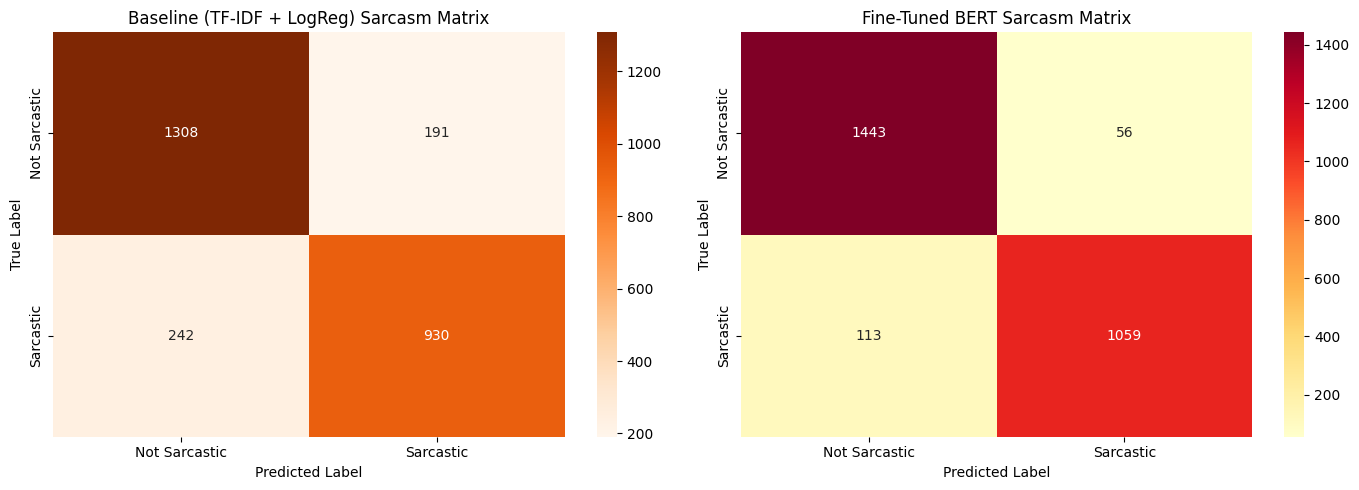

In [ ]:
print("Extracting predictions from Sarcasm BERT model...")
sarc_predictions_output = sarc_trainer.predict(sarc_test_dataset)
sarc_logits = sarc_predictions_output.predictions
sarc_bert_preds = np.argmax(sarc_logits, axis=-1)
y_sarc_test = sarc_test_df["is_sarcastic"].values

# Calculate Global Metrics for the Sarcasm Task
sarc_bert_acc = accuracy_score(y_sarc_test, sarc_bert_preds)
sarc_bert_f1 = f1_score(y_sarc_test, sarc_bert_preds, average="macro")

# Re-calculate Sarcasm Baseline predictions on the exact same test subset
sarc_baseline_test_preds = sarc_baseline_model.predict(X_sarc_test)
sarc_base_acc = accuracy_score(y_sarc_test, sarc_baseline_test_preds)
sarc_base_f1 = f1_score(y_sarc_test, sarc_baseline_test_preds, average="macro")

# Print Comparative Performance Summary Table
print("\n" + "=" * 50)
print(f"{'SARCASM TASK PERFORMANCE COMPARISON':^50}")
print("=" * 50)
print(f"Classical ML Baseline (TF-IDF + LogReg):")
print(f"  - Test Accuracy : {sarc_base_acc*100:.2f}%")
print(f"  - Macro F1-Score: {sarc_base_f1*100:.2f}%")
print("-" * 50)
print(f"Fine-Tuned BERT Model:")
print(f"  - Test Accuracy : {sarc_bert_acc*100:.2f}%")
print(f"  - Macro F1-Score: {sarc_bert_f1*100:.2f}%")
print("=" * 50)

# Plot Side-By-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline Sarcasm Matrix
cm_sarc_base = confusion_matrix(y_sarc_test, sarcasm_baseline_test_preds) if 'sarcasm_baseline_test_preds' in locals() else confusion_matrix(y_sarc_test, sarc_baseline_test_preds)
sns.heatmap(
    cm_sarc_base,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[0],
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
)
axes[0].set_title("Baseline (TF-IDF + LogReg) Sarcasm Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# BERT Sarcasm Matrix
cm_sarc_bert = confusion_matrix(y_sarc_test, sarc_bert_preds)
sns.heatmap(
    cm_sarc_bert,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    ax=axes[1],
    xticklabels=["Not Sarcastic", "Sarcastic"],
    yticklabels=["Not Sarcastic", "Sarcastic"],
)
axes[1].set_title("Fine-Tuned BERT Sarcasm Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# Save Predictions to Sarcasm Test DataFrame for Qualitative Error Analysis
sarc_test_df = sarc_test_df.copy()
sarc_test_df["baseline_pred"] = sarc_baseline_test_preds
sarc_test_df["bert_pred"] = sarc_bert_preds

In [54]:
def predict_sarcasm(headline_text):
    # 1. Ensure the running model is set to evaluation mode
    sarc_model.eval()
    
    # 2. Tokenize the input headline using the optimized 64-token sequence structure
    inputs = sarc_tokenizer(
        headline_text,
        add_special_tokens=True,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    # 3. Push token tensors onto your GPU memory
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    # 4. Generate prediction logits without updating model weights
    with torch.no_grad():
        outputs = sarc_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        # Calculate soft probabilities using softmax
        probabilities = torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()[0]
        predicted_class = np.argmax(probabilities)
        
    # 5. Format and display results
    label_map = {0: "NOT SARCASTIC (HuffPost style)", 1: "SARCASTIC (The Onion style)"}
    print(f"\nHeadline: \"{headline_text}\"")
    print(f"Prediction: {label_map[predicted_class]}")
    print(f"Confidence: Non-Sarcastic: {probabilities[0]*100:.2f}% | Sarcastic: {probabilities[1]*100:.2f}%")

# ==============================================================================
# RUNNING THE TESTS
# ==============================================================================
print("--- Checking Custom Examples with Fine-Tuned BERT ---")

# Test Example A: A real factual news headline style
predict_sarcasm("Government officials announce new infrastructure funding plans for local transit.")

# Test Example B: An ironic, classic satirical headline style
predict_sarcasm("Local man turns into expert epidemiologist after reading two social media posts.")

# Test Example C: Testing an actual row from your raw dataset introduction
predict_sarcasm("former versace store clerk sues over secret 'black code' for minority shoppers")

--- Checking Custom Examples with Fine-Tuned BERT ---

Headline: "Government officials announce new infrastructure funding plans for local transit."
Prediction: NOT SARCASTIC (HuffPost style)
Confidence: Non-Sarcastic: 98.19% | Sarcastic: 1.81%

Headline: "Local man turns into expert epidemiologist after reading two social media posts."
Prediction: SARCASTIC (The Onion style)
Confidence: Non-Sarcastic: 0.14% | Sarcastic: 99.86%

Headline: "former versace store clerk sues over secret 'black code' for minority shoppers"
Prediction: NOT SARCASTIC (HuffPost style)
Confidence: Non-Sarcastic: 99.78% | Sarcastic: 0.22%
